In [1]:
# Import the RAAE Library

import numpy as np
import matplotlib.pyplot as plt

from qiskit_aer import AerSimulator

import raae_state_preparation as raae_sp

In [2]:
# Step 0
# ----------------------------------------
# Prepare the state vector we would like to create

N = 4 # Number of qubits

input_vector = raae_sp.normalize(np.random.random(2**N))

In [3]:
# Step 1
# ----------------------------------------
# Create circuit placeholder

raae = raae_sp.RAAECircuitBuilder(2**N)

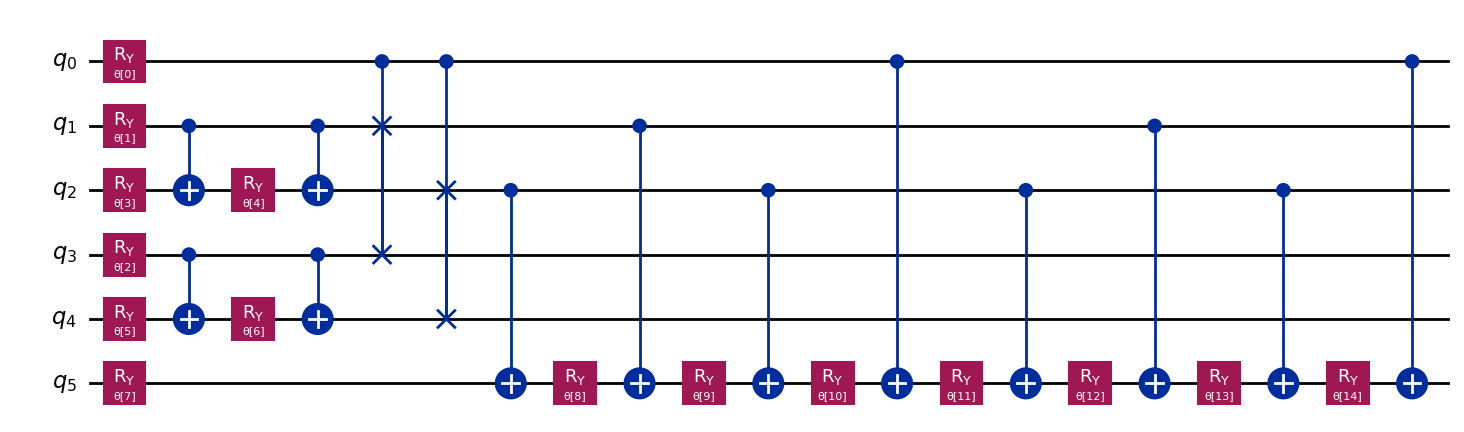

In [4]:
# Step 1.A
# ----------------------------------------
# Base circuit

raae_base = raae.get_circuit()
raae_base.draw('mpl')

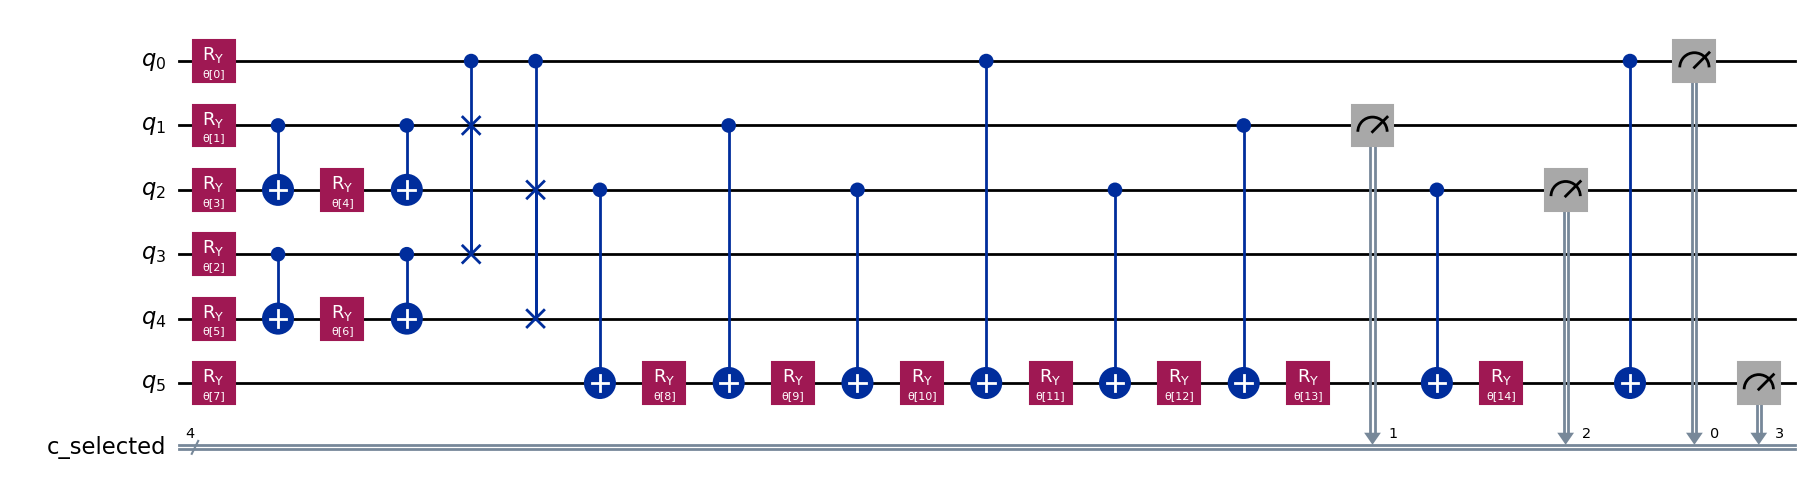

In [5]:
# Step 1.B
# ----------------------------------------
# Circuit with measurement line for job execution

raae_meas = raae.get_circuit_with_measurement()
raae_meas.draw('mpl')

In [6]:
# Step 2
# ----------------------------------------
# Create data converter tool
# for converting classical data -> parameters for quantum circuit

myConverter = raae_sp.StateConverter()
params = myConverter.convert_to_params(input_vector)

In [7]:
# Step 3
# ----------------------------------------
# Run simulator and measure it
bound_raae_meas = raae_meas.assign_parameters(params)

shots = 1024*(2**N)

backend = AerSimulator()
job = backend.run(bound_raae_meas, shots=shots)
result = job.result()
counts = result.get_counts(bound_raae_meas)

In [8]:
# Step 4
# ----------------------------------------
# Convert to probability vector
sim_probabilities = myConverter.to_probabilities(counts)

# Or convert to amplitude vector
sim_amplitudes = myConverter.to_amplitudes(counts)

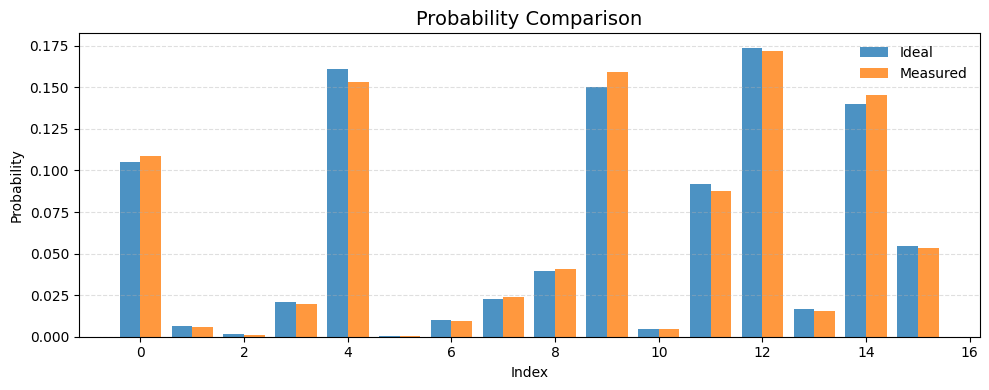

In [9]:
# See the prepared states and
# the original intended states
# ----------------------------------------

x = np.arange(len(input_vector))
width = 0.4

plt.figure(figsize=(10, 4))

# Bars
plt.bar(
    x - width/2,
    input_vector**2,
    width=width,
    label="Ideal",
    alpha=0.8
)

plt.bar(
    x + width/2,
    sim_probabilities,
    width=width,
    label="Measured",
    alpha=0.8
)

# Styling
plt.title("Probability Comparison", fontsize=14)
plt.xlabel("Index")
plt.ylabel("Probability")
plt.legend(frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()